# **QUASI RANDOM NUMBER GENERATOR(UNIFORM)**

## **LOW DISCREPANCY SEQUENCE(QUASI RANDOM NUMBER GEN):**
- **MOTIVATION:**
- Is desire to use a sequence that has a low discrepancy in myy MC method: $\frac{1}{n} \sum_{i=1}^{n} f(x)$
- For example, if we just take $x_i = \frac{i\cdot1}{n}$ with discrepancy $1/n$, and w increase $n$ by 1, then we have to recreate the whole sequence.
- With MC we can add the points that we want, and when we talk about lowe discrepancy sequence we wish to have this property. 

- So let's go with the explanation of the low discrepancy sequence:
    - The idea is to generate an infinite sequence of numbers, such that ***`for every subsequence 1, ..., m the subsequence has low discrepancy.`*** This allows to increase the accuracy by jus adding more and more functional evaluations. 

<p align="center">
    <img src='image-11.png' width='500' height='80'>
</p>

### **VAN DER CORPUT SEQUENCE:**
- The sequence above is called the **Van der Corput sequence**.
- A good simple example of a *low discrepancy sequence*
- The *Van der Corput Sequence* $\{x_i\}_{i \in \mathbb{N}} \subset [0, 1]$ has a parameter b such that $b \in \mathbb{N}, b>1$, and is defined by: 

$$
x_i: \sum_{j=1}^{\infty} \alpha_{i, j} \cdot b^{-j}, 
$$

- where $\alpha_{i, j}$ are such that $i = \sum_{j=1}^{\infty} \alpha_{i, j} \cdot b^{j-1}$ wwith $\alpha_{i, j} \in \{0, ..., b-1\}$
- **The sum is finit because $\alpha_{i, j}$ are zero for j sufficiently large**
    - For b = 2, the $\alpha_{i, j} \in \{0, 1\}$ are the binary representation of the index $i$. 
    <p align='center'>
    <img src='image-13.png' width='450' height='350'>
    </p>

- #### **THE STAR DISCREPANCY**
- The star discrepancy in the VCS is defined as:
$$
O(\frac{log(n)}{n})
$$

> Almost $O(\frac{1}{n})$, but with the advantage that we can add more points without having to recreate the whole sequence.

> Much better than randomly generated points, $O(\frac{1}{\sqrt{n}})$, and does not generate clusters or gaps in the sequence.

> Infinite sequence, so we can always add more points to the sequence with low discrepancy, better whan MC method. 

> This allows us to parallelize the integration algorithm on a multi-core machine. (In MC method we need to generate random numbers, but if we need to save or regenerate the same seed it would be a problem, that doesn't happen with the VCS)

> The sequence $X_i$ is a function of the index $i$

In [1]:
import VanDerCorputSeq as vdcs
import MonteCarlo as mc

In [2]:
van_der_corput_seq = vdcs.VanDerCorputSequenceExperiment()
van_der_corput_seq.run()

i=0	x_i=0.5
i=1	x_i=0.25
i=2	x_i=0.75
i=3	x_i=0.125
i=4	x_i=0.625
i=5	x_i=0.375
i=6	x_i=0.875
i=7	x_i=0.0625
i=8	x_i=0.5625
i=9	x_i=0.3125


#### **COMPARISONS BETWEEN MONTE CARLO AND OTHER INTEGRATION METHODS**

In [3]:
test = mc.Integrator1DExperiment()
test

Testing several implementations of a 1D integrator.
              (Note that some implementations may use Kahan summation or similar techniques.)
Number of evaluation points....: 10001 (≈ 1.00e+04)

Theoretical (relative) errors are:
	Monte-Carlo integration.......(1/n)^0.5..: 1.00e-02
	Simpson's rule integration....(1/n)^4....: 1.00e-16

SimpsonsIntegrator1D                         -0.9589242746631377  ± 7.772e-16
SimpsonsIntegrator1DWithStreams              -0.9589242746631389  ± 4.441e-16
MonteCarloIntegrator1D                       -0.9921573721286792  ± 3.323e-02
MonteCarloIntegrator1DWithStreams            -0.9523324603356010  ± 6.592e-03
QuasiMonteCarloIntegrator1D                  -0.9587451881425600  ± 1.791e-04
QuasiMonteCarloIntegrator1DWithStreams       -0.9587451881425647  ± 1.791e-04
RiemannMidPointIntegrator1D                  -0.9589242846499322  ± 9.987e-09
RiemannMidPointIntegrator1DWithStreams       -0.9589242846499356  ± 9.987e-09
MonteCarloIntegrator1DFromRandomGen

## **CODING SESSION**

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class DiscrepancyExperiment():
    def analyze(label, samples):
        D = DiscrepancyExperiment.getDiscrepancy(samples)
        print(f"{label:>32} \t D = {D:.6f}")
        DiscrepancyExperiment.plotDiscrepancyFunction(label, samples)

    def getDiscrepancy(samples):
        sample_sorted = sorted(samples)
        discrepance = 0.0
        count = 0

        for sample in sample_sorted: #For a sample point x_i ... 
            low = sample - count/len(samples) #... evaluate lambda([0,x)) - i/n = x - i/n ...
            count = count + 1 #... and (i+i)/n - lambda([0,x]) = i+1/n - x ...
            high = count/len(samples) - sample

            discrepance = max(discrepance, max(low, high))

        return discrepance
    
    def plotDiscrepancyFunction(label, samples):
        n = len(samples)
        samples = np.array(samples)

        def lambda_diff(x):
            return x - np.sum(samples < x) / n
        
        x_val = np.linspace(0, 1, 1000)
        y_val = [lambda_diff(x) for x in x_val]

        plt.figure(figsize=(30, 10))
        plt.plot(x_val, y_val, label = 'λ([0,x)) - empírical', linewidth=4)
        plt.scatter(samples, np.zeros_like(samples), color = 'brown', label='sample', s=120)
        plt.ylim(-0.5, 0.5)
        plt.title(label)
        plt.xlabel('x')
        plt.ylabel('λ([0,x)) - |xᵢ ∈ [0,x)| / n')
        plt.grid(True)
        plt.legend()
        plt.show()


    def __init__(self):
        vdc = vdcs.VanDerCorputSequence(2)
        VanDerCorputSequenceExperiment5 = [vdc.nextDouble() for _ in range(5)]
        VanDerCorputSequenceExperiment7 = [vdc.nextDouble() for _ in range(7)]
        VanDerCorputSequenceExperiment9 = [vdc.nextDouble() for _ in range(9)]
        VanDerCorputSequenceExperiment12 = [vdc.nextDouble() for _ in range(12)]

        print("\nRandom, n=5")
        np.random.seed(3216)
        samples = np.random.rand(5).tolist()
        DiscrepancyExperiment.analyze("Random, n=5", samples)

        print("\nRefined sets")
        DiscrepancyExperiment.analyze("Refined left to right, n=5",
                                    [1.0/8, 2.0/8, 3.0/8, 2.0/4, 3.0/4])
        
        DiscrepancyExperiment.analyze("Refined like v.d.C., n=5",
                                    [1.0/8, 2.0/8, 2.0/4, 5.0/8, 3.0/4])
        
        DiscrepancyExperiment.analyze("Van Der Corput, n=5", VanDerCorputSequenceExperiment5)
        DiscrepancyExperiment.analyze("Van Der Corput, n=7", VanDerCorputSequenceExperiment7)
        DiscrepancyExperiment.analyze("Van Der Corput, n=9", VanDerCorputSequenceExperiment9)
        DiscrepancyExperiment.analyze("Van Der Corput, n=12", VanDerCorputSequenceExperiment12)

        vdc = vdcs.VanDerCorputSequence(2)



Random, n=5
                     Random, n=5 	 D = 0.461166


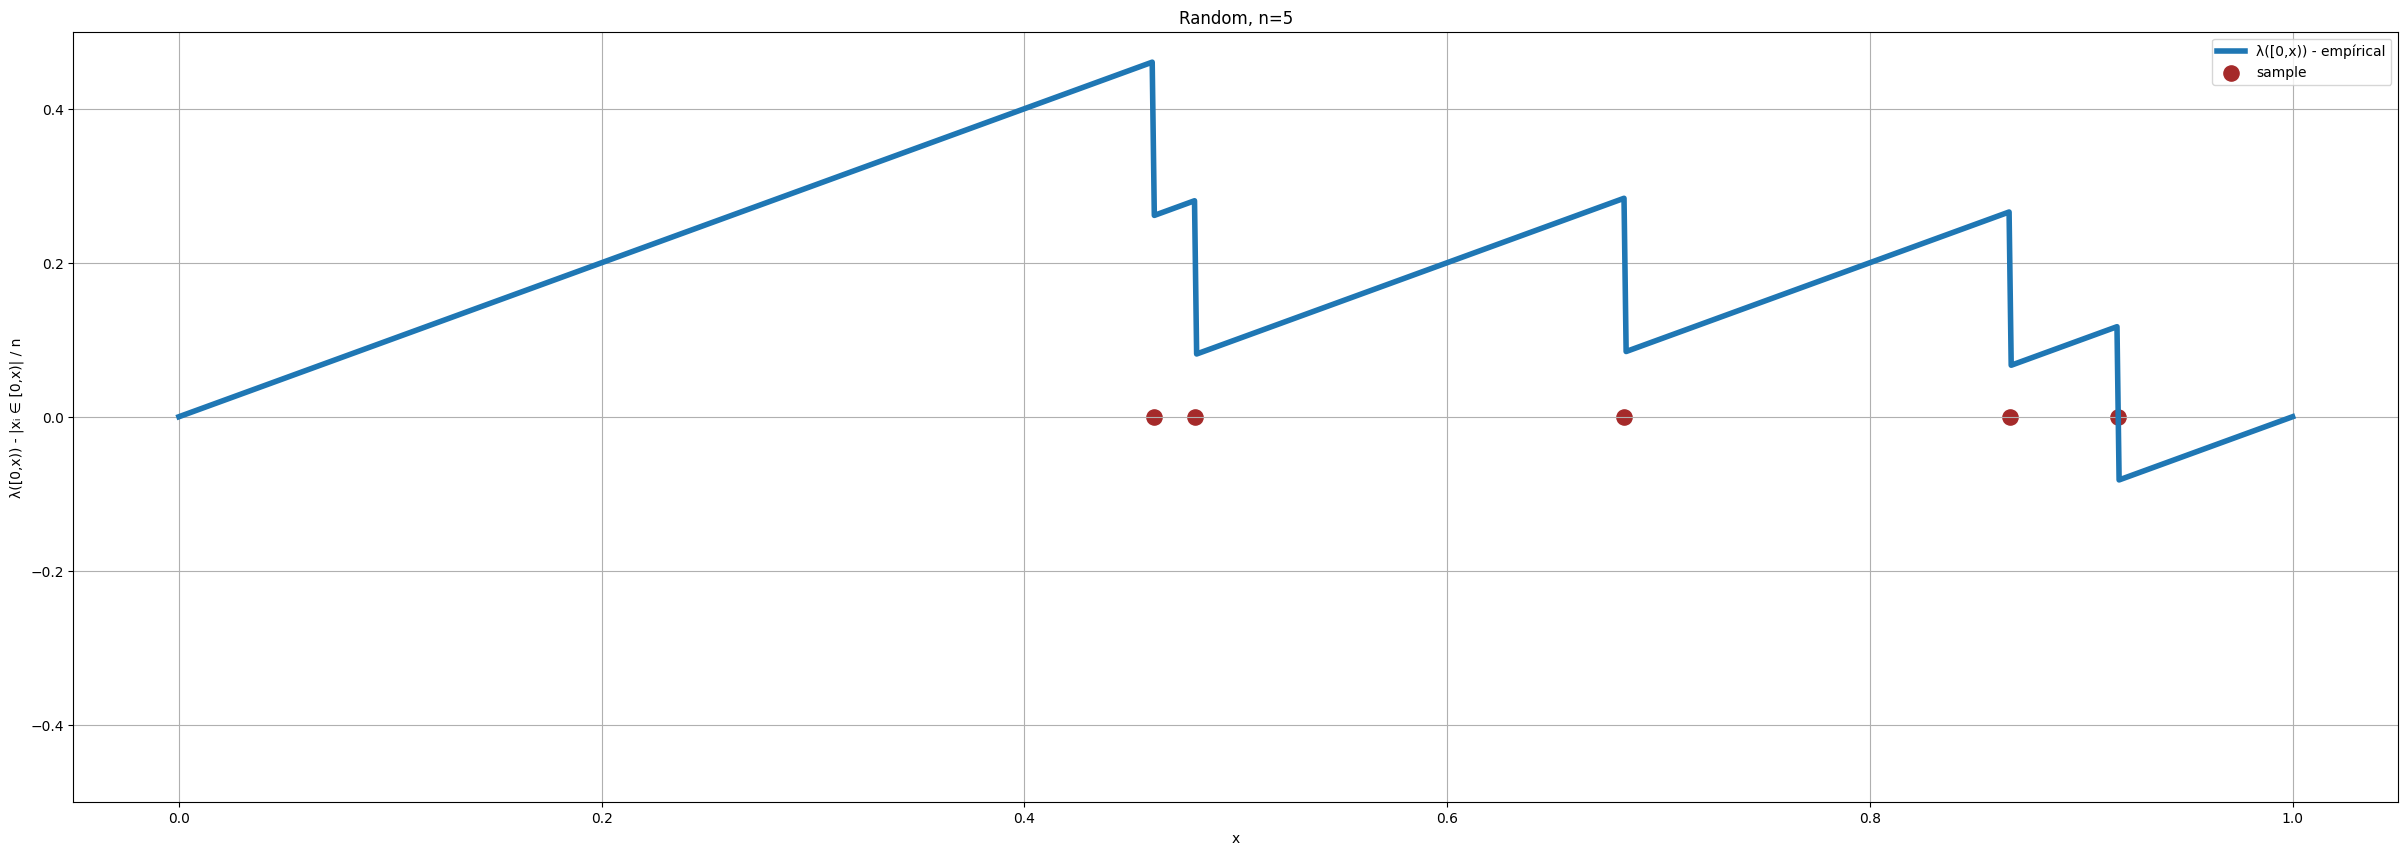


Refined sets
      Refined left to right, n=5 	 D = 0.300000


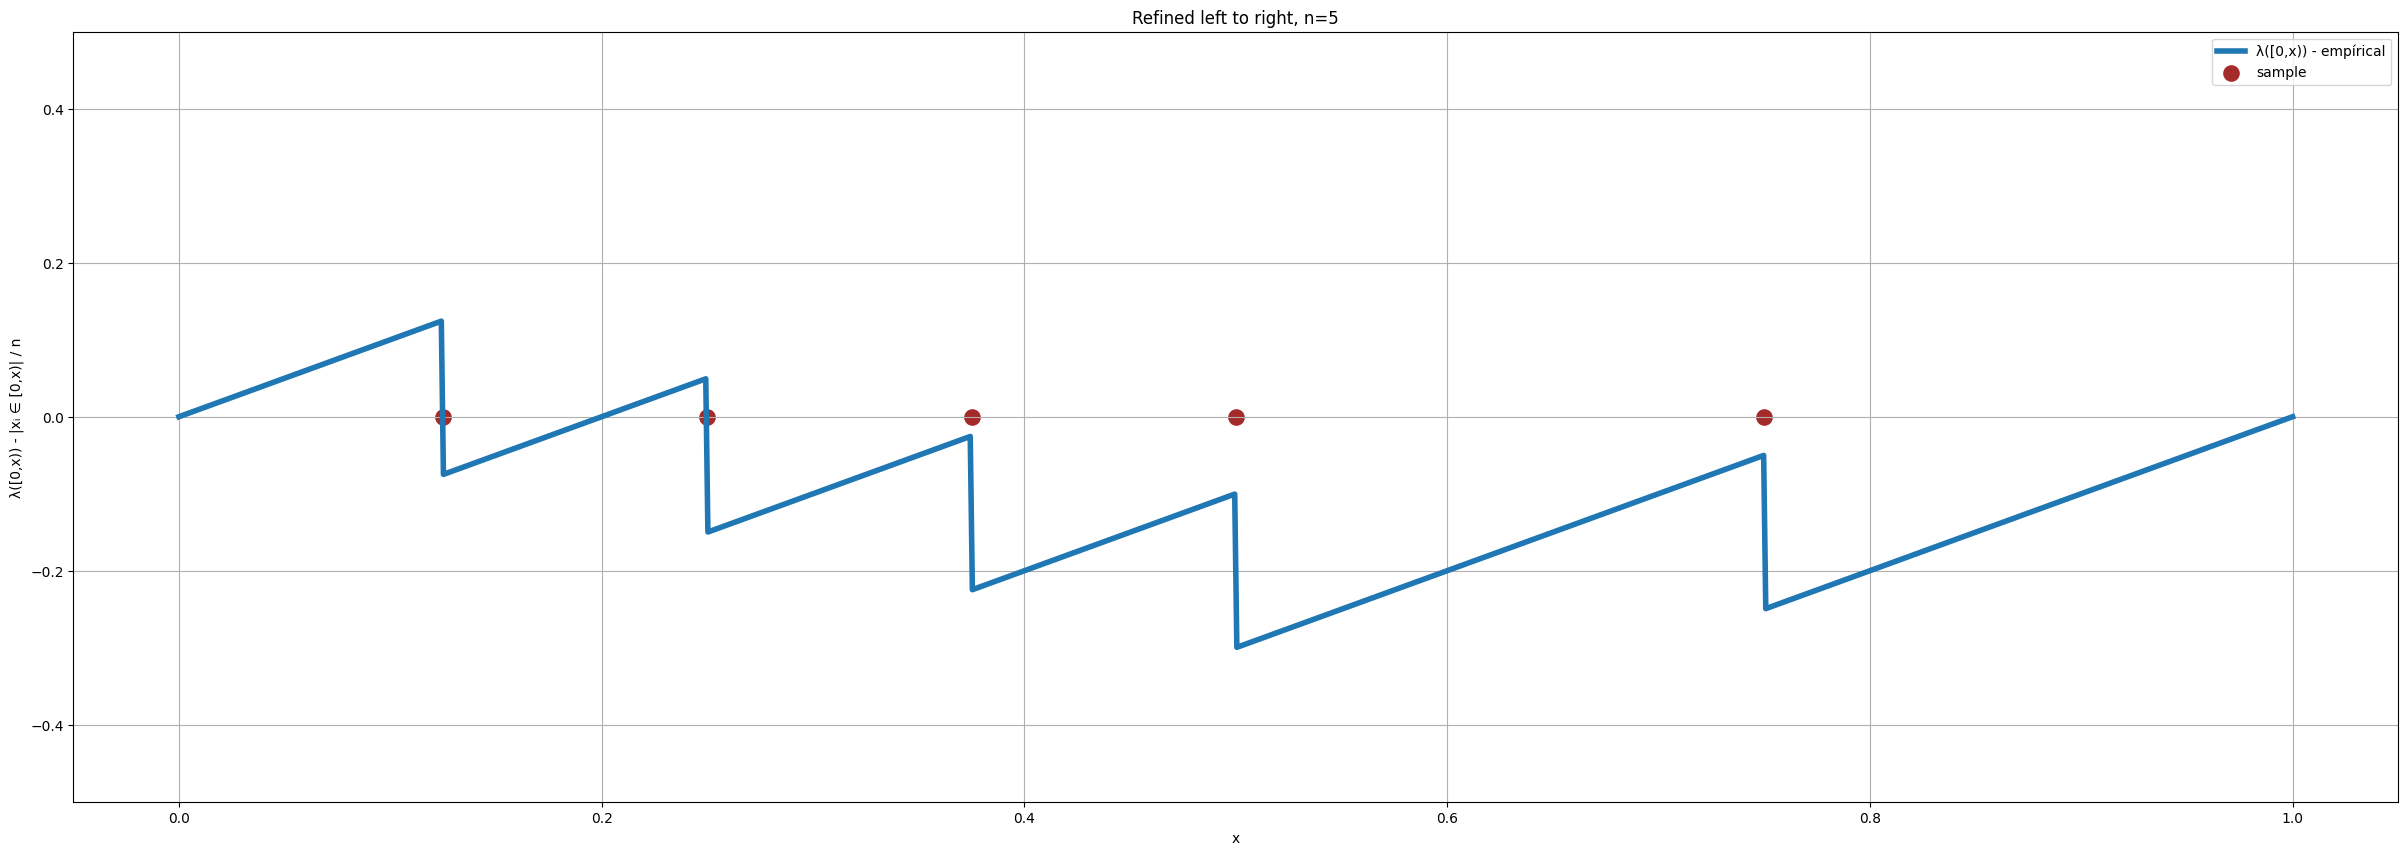

        Refined like v.d.C., n=5 	 D = 0.250000


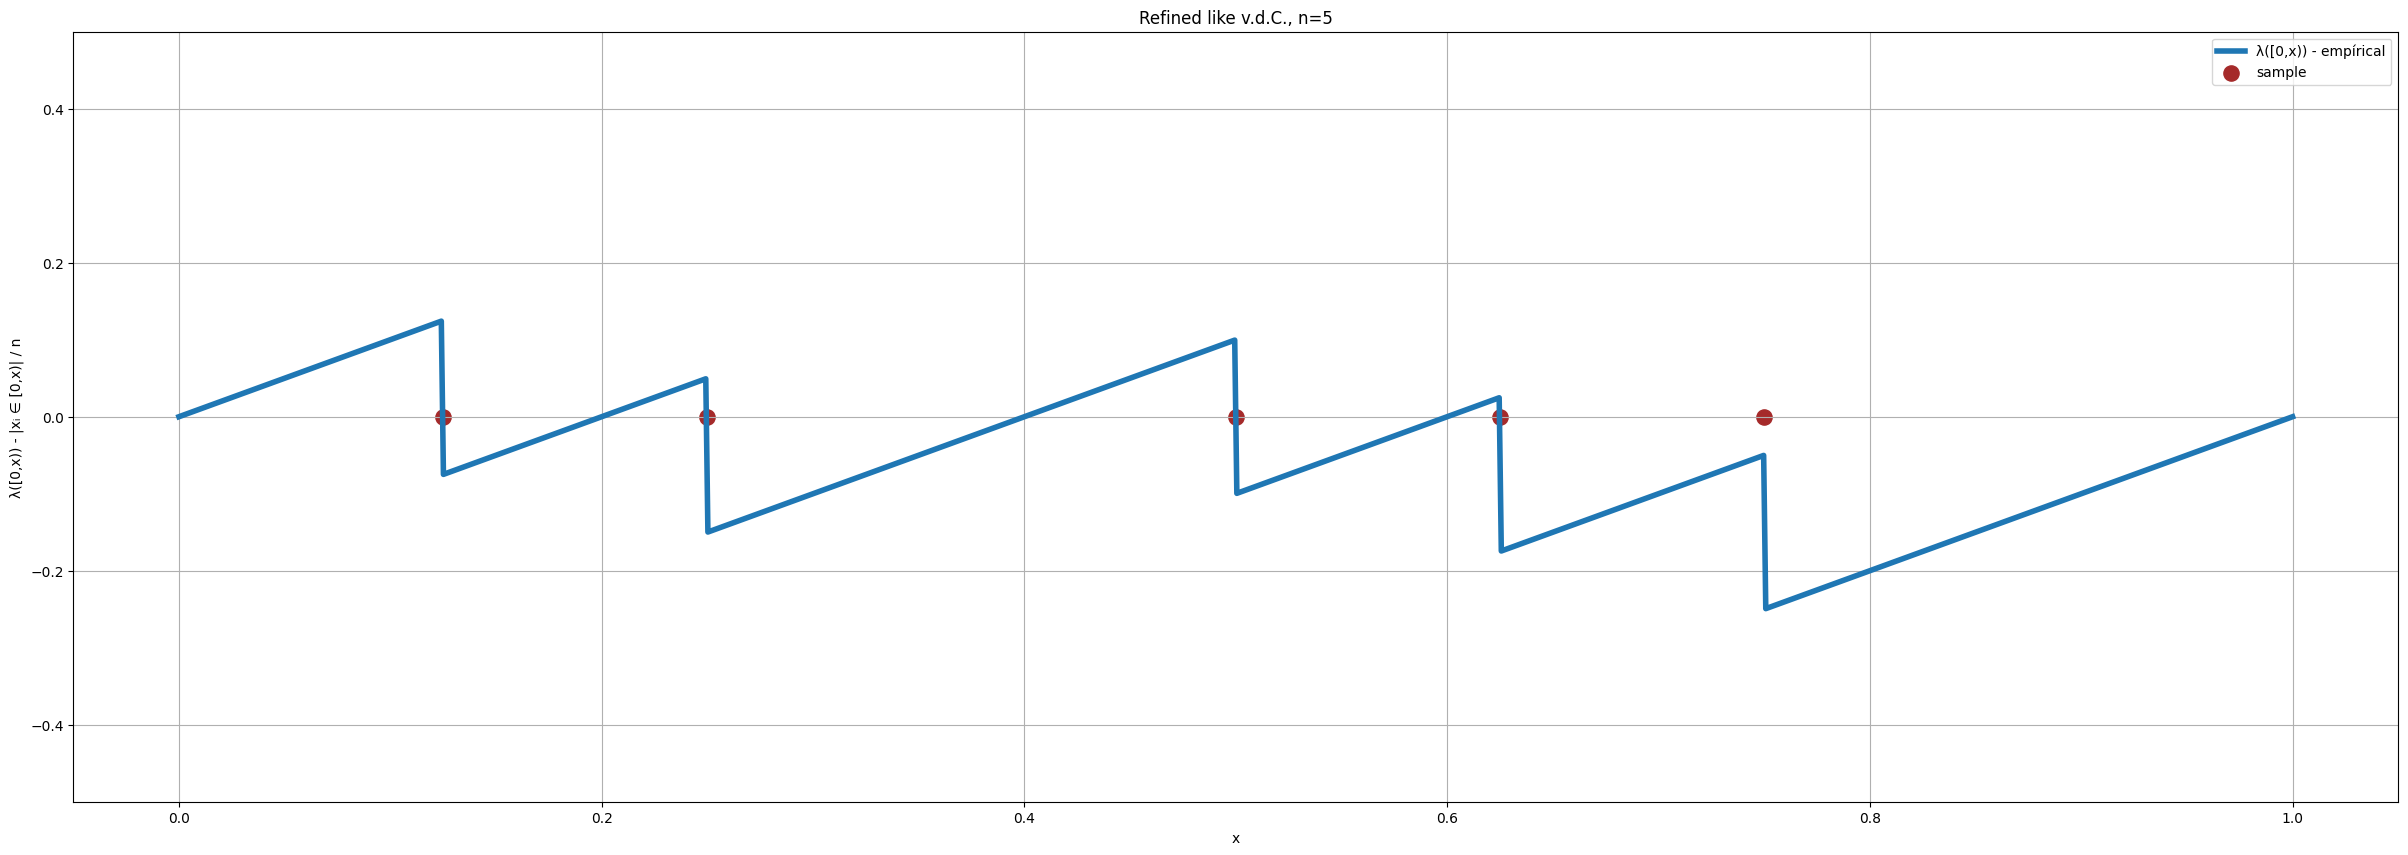

             Van Der Corput, n=5 	 D = 0.250000


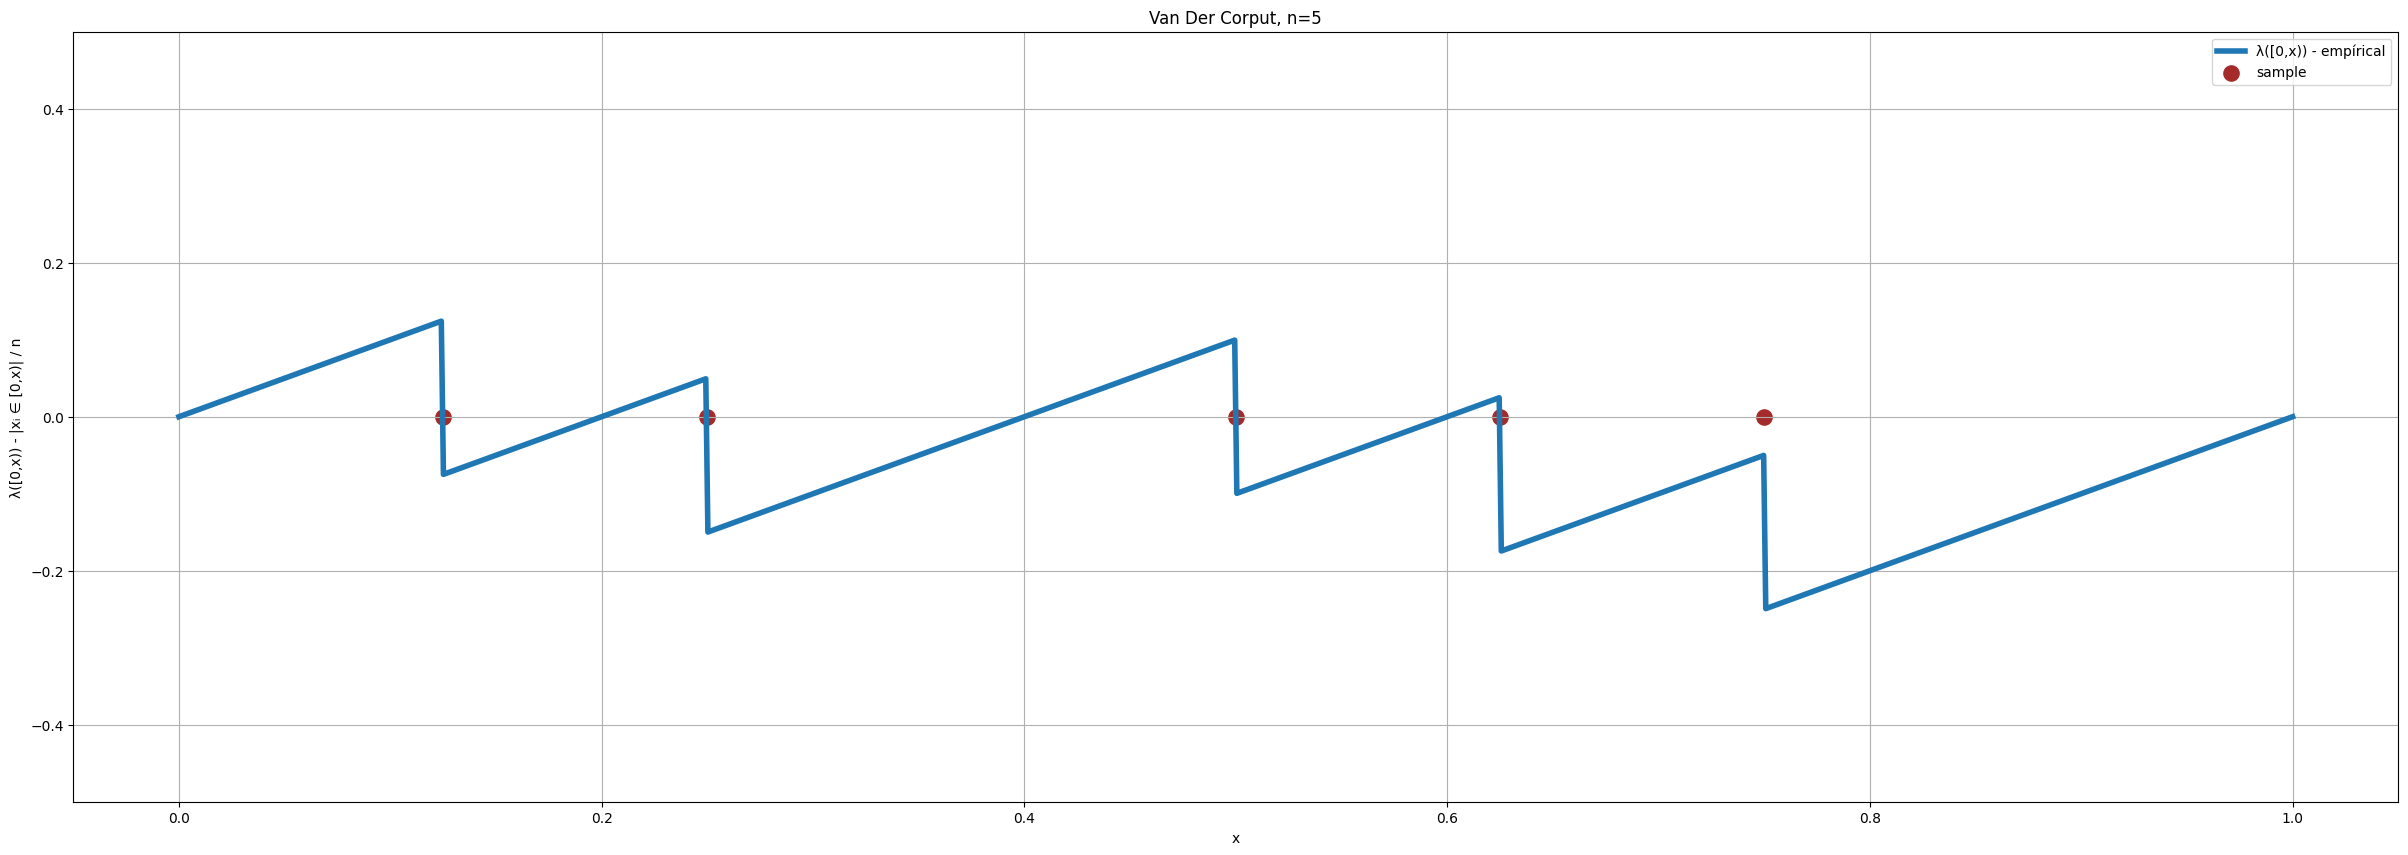

             Van Der Corput, n=7 	 D = 0.196429


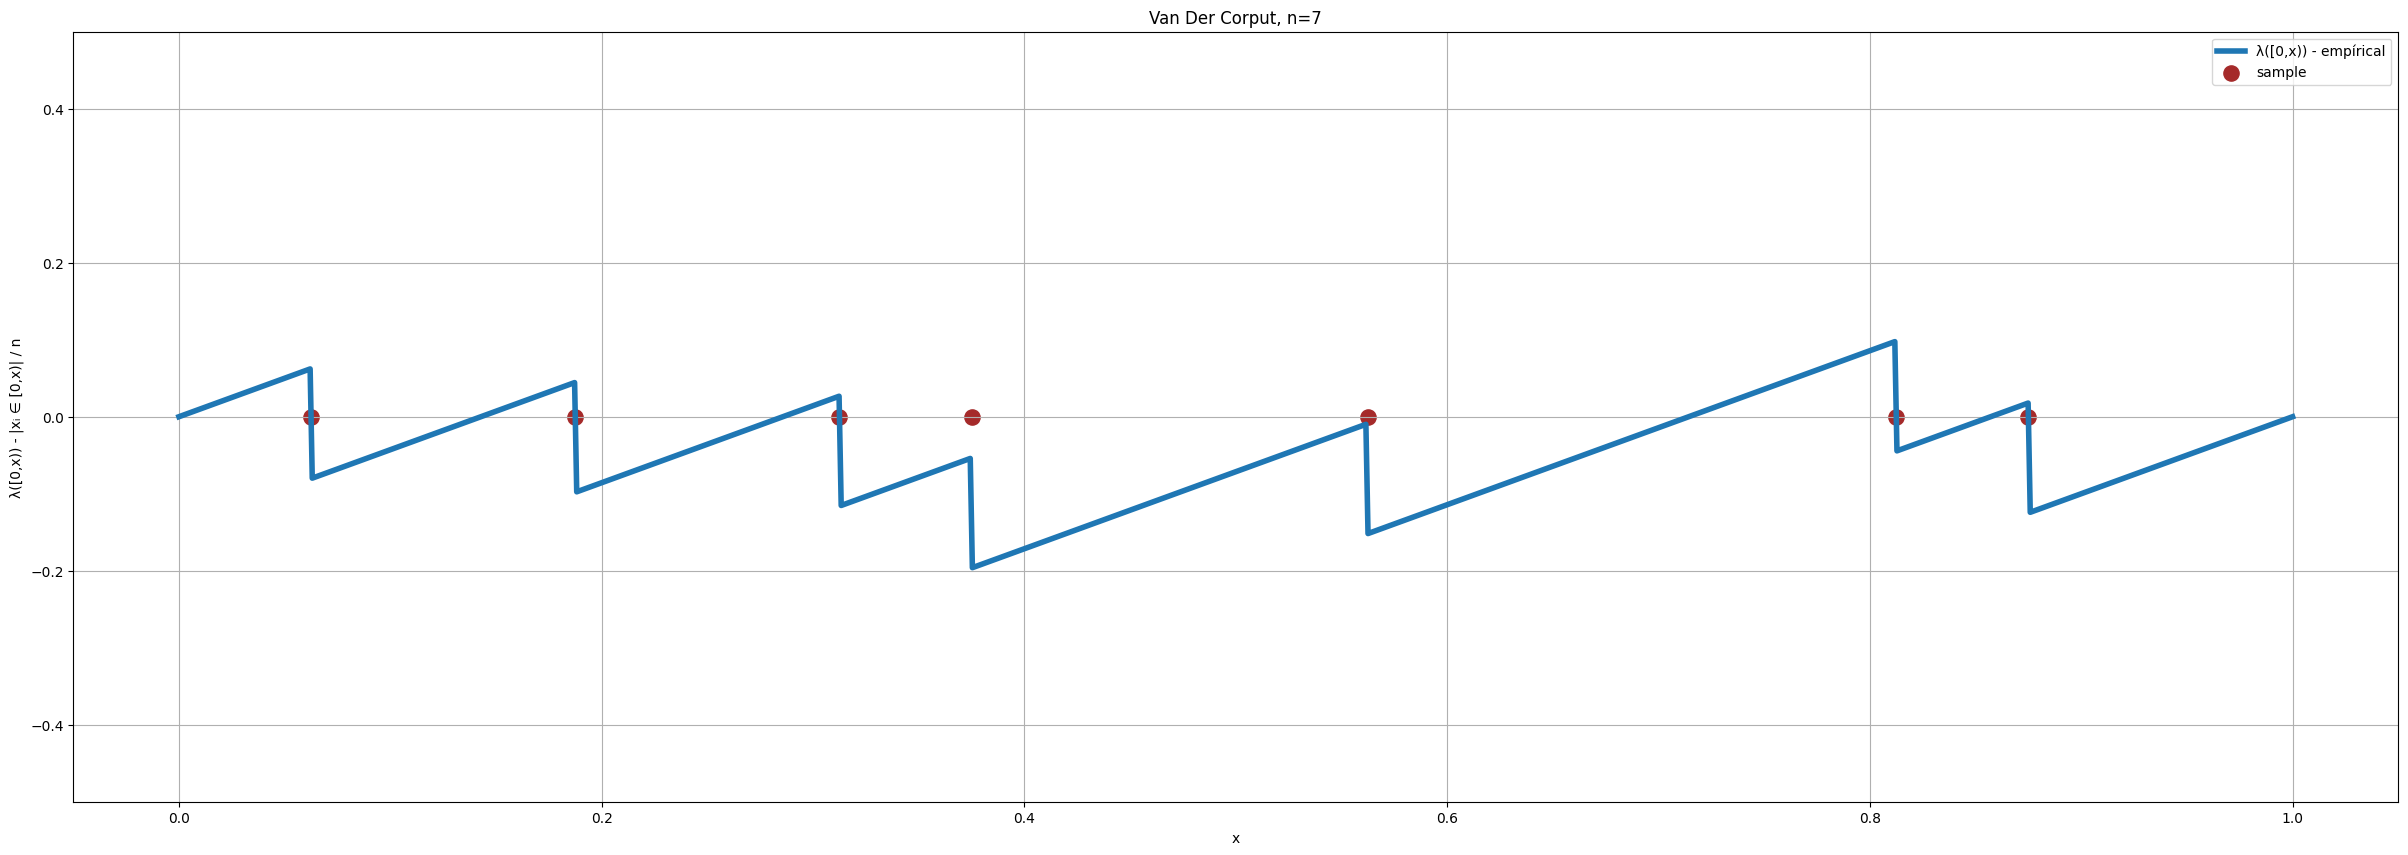

             Van Der Corput, n=9 	 D = 0.107639


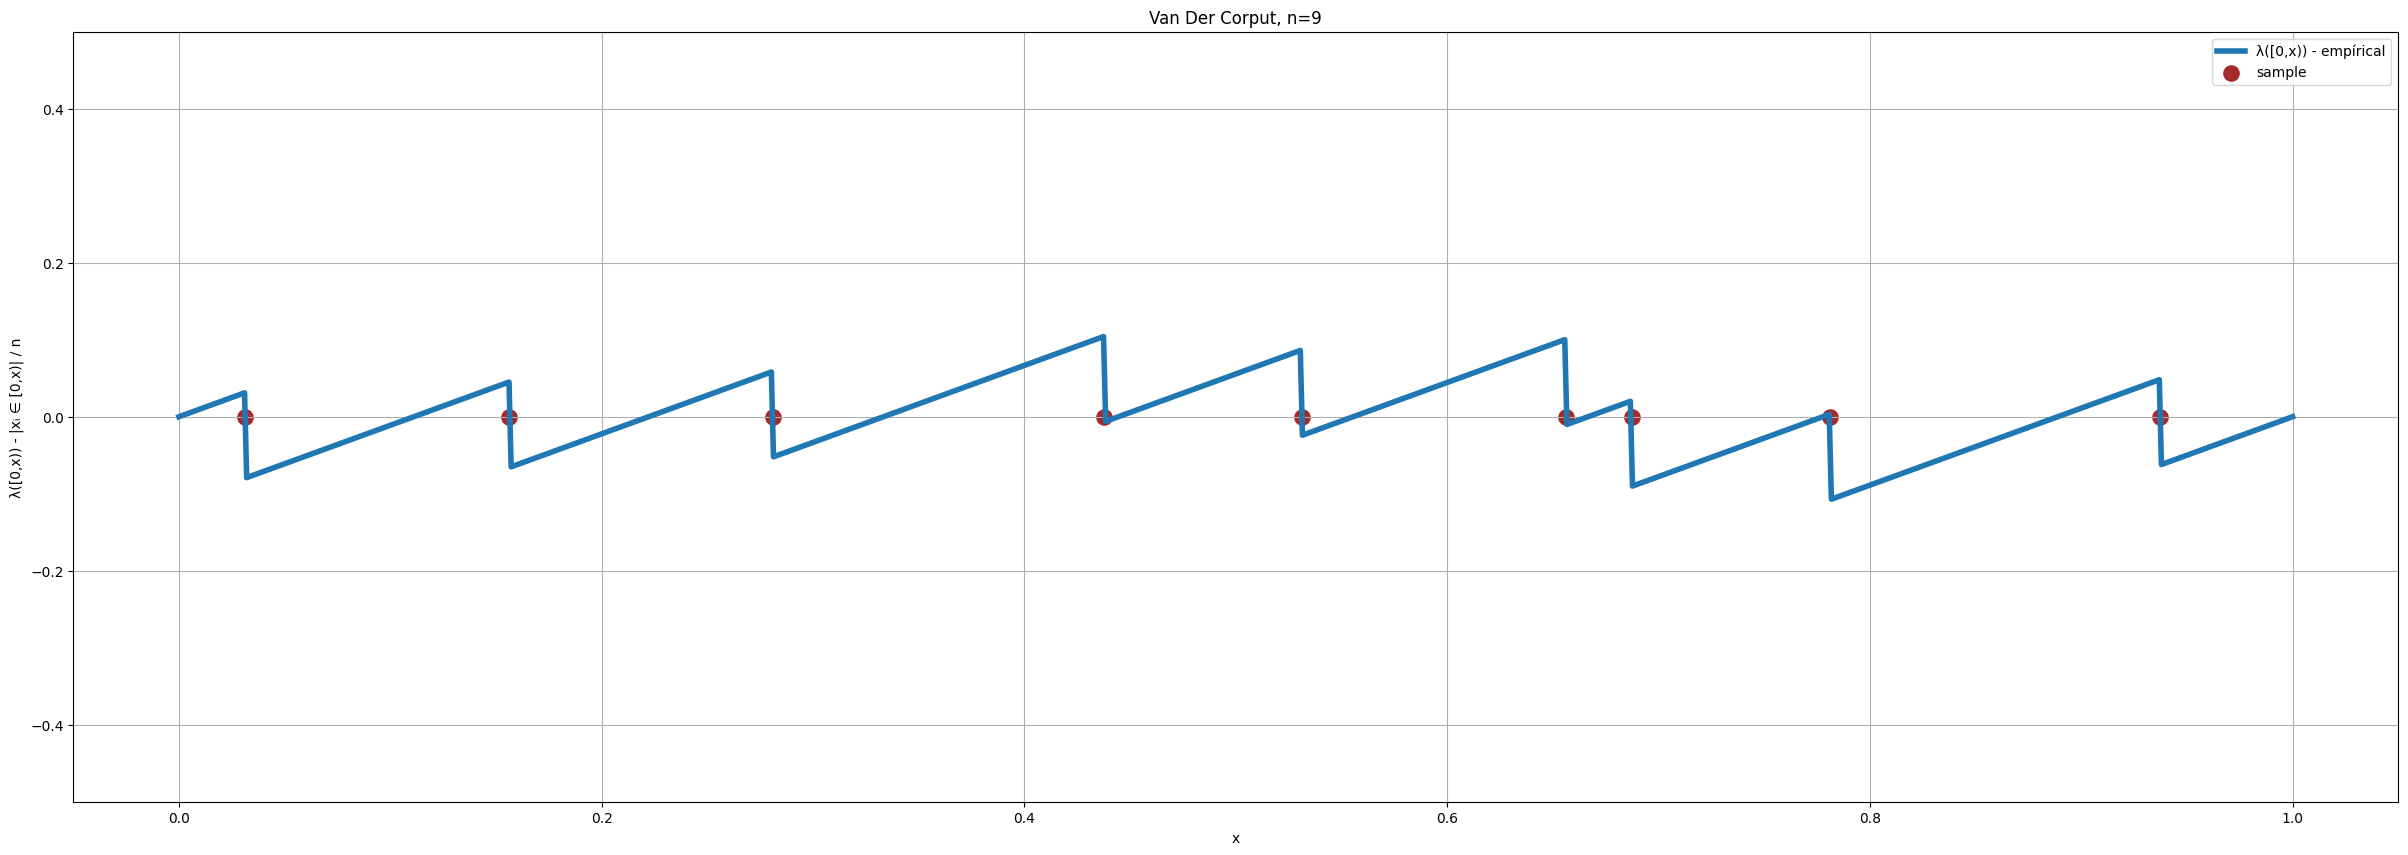

            Van Der Corput, n=12 	 D = 0.093750


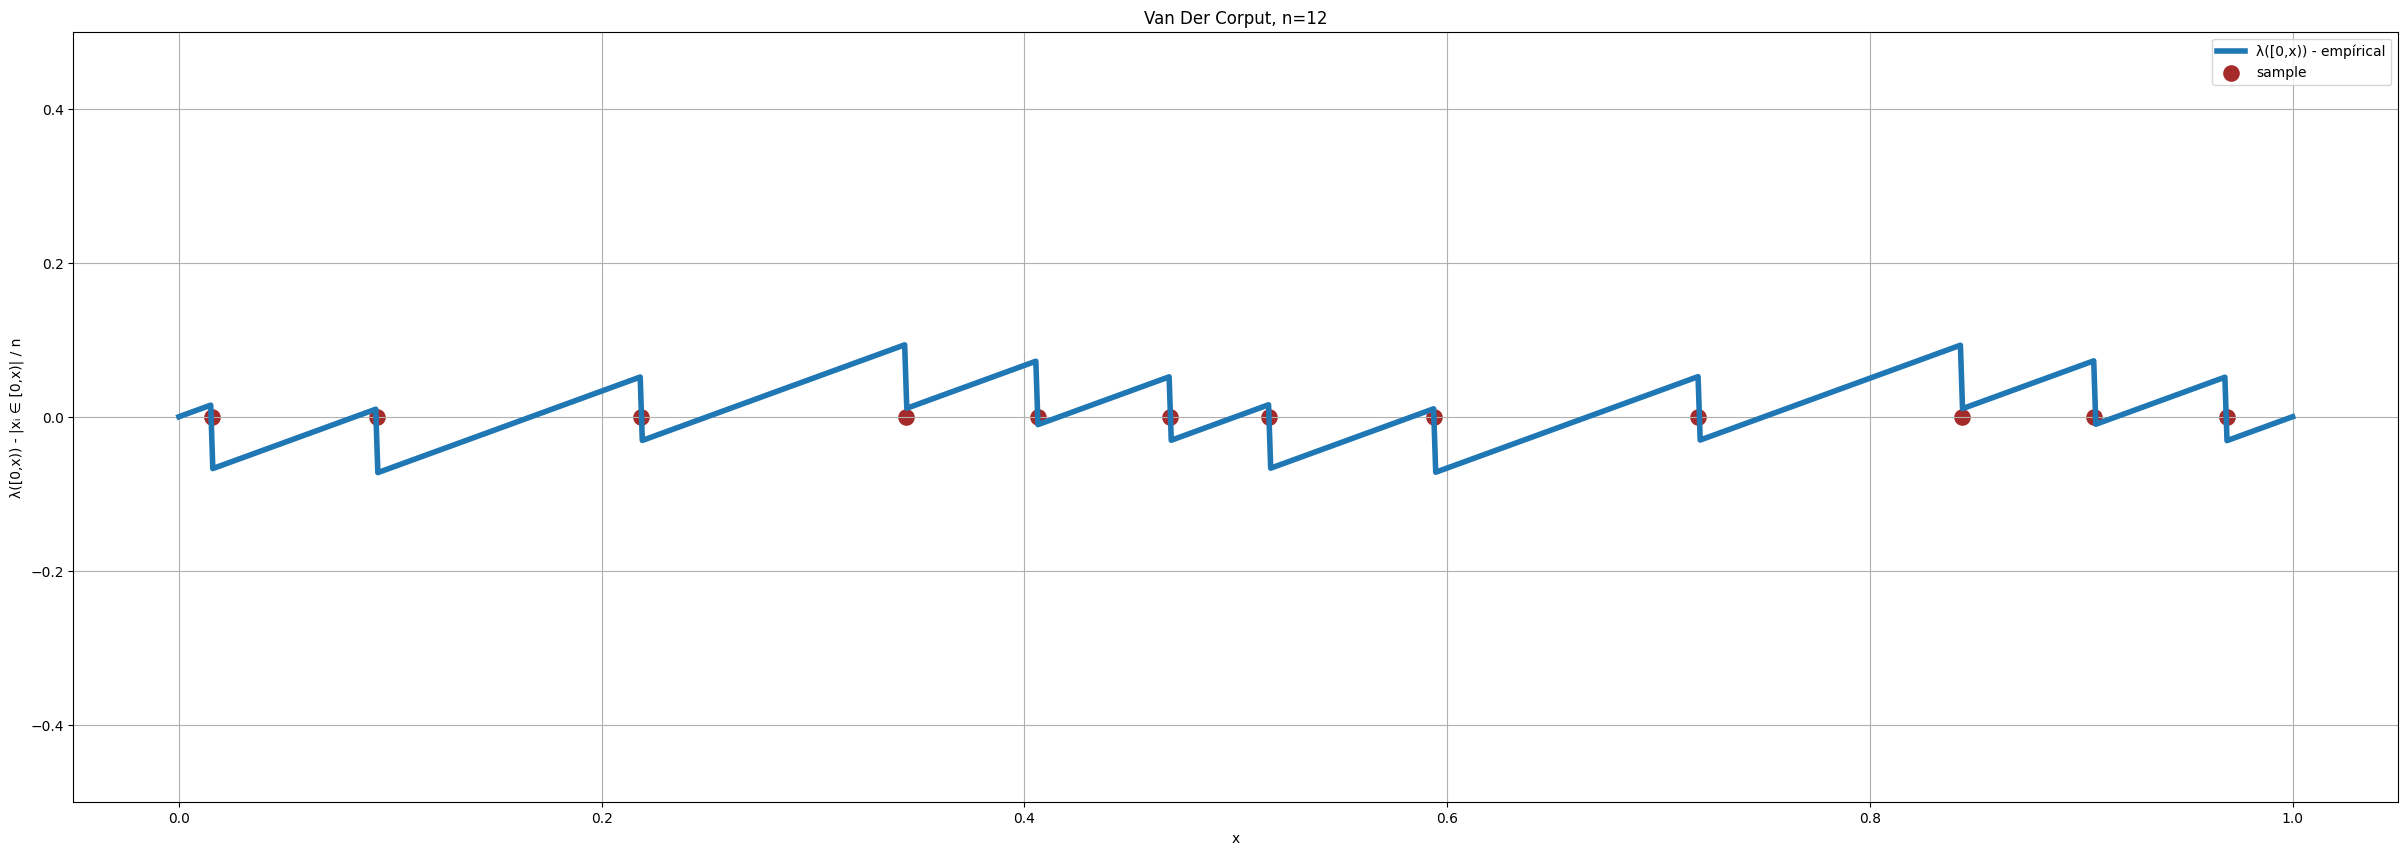

Samples n=5: [0.5, 0.25, 0.75, 0.125, 0.625]
Sorted n=5: [0.125, 0.25, 0.5, 0.625, 0.75]
Discrepancia n=5: 0.25
Samples n=7: [0.375, 0.875, 0.0625, 0.5625, 0.3125, 0.8125, 0.1875]
Sorted n=7: [0.0625, 0.1875, 0.3125, 0.375, 0.5625, 0.8125, 0.875]
Discrepancia n=7: 0.1964285714285714
Samples n=9: [0.6875, 0.4375, 0.9375, 0.03125, 0.53125, 0.28125, 0.78125, 0.15625, 0.65625]
Sorted n=9: [0.03125, 0.15625, 0.28125, 0.4375, 0.53125, 0.65625, 0.6875, 0.78125, 0.9375]
Discrepancia n=9: 0.10763888888888884
Samples n=12: [0.40625, 0.90625, 0.09375, 0.59375, 0.34375, 0.84375, 0.21875, 0.71875, 0.46875, 0.96875, 0.015625, 0.515625]
Sorted n=12: [0.015625, 0.09375, 0.21875, 0.34375, 0.40625, 0.46875, 0.515625, 0.59375, 0.71875, 0.84375, 0.90625, 0.96875]
Discrepancia n=12: 0.09375


In [6]:
DiscrepancyExperiment()


<img src='image-14.png' width='800' height='300'>

```python